In [1]:
import sys, os
# ensure parent directory is on the path so `src` package can be imported
sys.path.insert(0, os.path.abspath('..'))

In [2]:
# configura per importare da src
import sys
sys.path.append('./src')

## Box creation

### Load dataset

In [3]:
import re

concepts_file = '../AwA2_Dataset_Labels/Animals_with_Attributes2/extended_concepts.txt'
def parse_concepts(filepath):
    """Legge il file dei concetti e restituisce una lista ordinata."""
    concepts = []
    with open(filepath, 'r', encoding='utf-8') as f:
        for line in f:
            # Rimuove eventuali tag come 
            line = re.sub(r'\\', '', line).strip()
            if not line:
                continue
            parts = line.split()
            # Assumiamo che il primo elemento sia l'ID e il resto il nome del concetto
            if len(parts) >= 2:
                concepts.append(parts[1])
    return concepts
concepts = parse_concepts(concepts_file)

In [4]:
import re

classes_file = '../AwA2_Dataset_Labels/Animals_with_Attributes2/classes.txt'
def parse_classes(filepath):
    """Legge il file delle classi e restituisce una lista ordinata."""
    classes = []
    with open(filepath, 'r', encoding='utf-8') as f:
        for line in f:
            # Rimuove eventuali tag come 
            line = re.sub(r'\\', '', line).strip()
            if not line:
                continue
            parts = line.split()
            # Assumiamo che il primo elemento sia l'ID e il resto il nome della classe
            if len(parts) >= 2:
                classes.append(parts[1])
    return classes

classes = parse_classes(classes_file)

In [5]:
import json

JSON_PATH='../AwA2_Dataset_Labels/Animals_with_Attributes2/supervisioni_gerarchia.json'
def load_data(json_path, concepts):
    with open(json_path, 'r') as f:
        data = json.load(f)
        
    concept2id = {c: idx for idx, c in enumerate(concepts)}
    id2concept = {idx: c for c, idx in concept2id.items()}
    
    # Prepariamo il dataset nel formato [(id_i, id_j, label), ...]
    dataset = []
    for item in data:
        dataset.append((concept2id[item[0]], concept2id[item[1]], float(item[2])))
        
    return dataset, concept2id, id2concept

In [6]:
dataset, concept2id, id2concept = load_data(JSON_PATH, concepts)

### Train

In [7]:
from src.CHM.model import BoxHierarchyModel
from src.CHM.train import train_box
import torch.nn as nn
from torch.optim import Adam

LR = 0.05

box_model = BoxHierarchyModel(num_concepts=len(concept2id), dim=32)
optimizer = Adam(box_model.parameters(), lr=LR)
criterion = nn.BCELoss() # Binary Cross Entropy

AllenNLP not available. Registrable won't work.


In [8]:
train_box(box_model, optimizer, criterion, dataset, concept2id, id2concept)

Trovati 55 concetti unici e 633 relazioni supervisionate.

Inizio Addestramento...
Epoca [1/100] | Loss: 1.6708
Epoca [10/100] | Loss: 0.2115
Epoca [20/100] | Loss: 0.0644
Epoca [30/100] | Loss: 0.0263
Epoca [40/100] | Loss: 0.0136
Epoca [50/100] | Loss: 0.0086
Epoca [60/100] | Loss: 0.0065
Epoca [70/100] | Loss: 0.0053
Epoca [80/100] | Loss: 0.0046
Epoca [90/100] | Loss: 0.0043
Epoca [100/100] | Loss: 0.0039

Addestramento completato!

Verifica di alcune predizioni post-addestramento:
Relazione: Animal | arm
 - P_teorica: 1.0 -> P_predetta: 0.9999
Relazione: leg | hops
 - P_teorica: 1.0 -> P_predetta: 1.0000
Relazione: yellow | wings
 - P_teorica: 0.0 -> P_predetta: 0.0000


### Visualization

In [9]:
from src.CHM.visualization import visualize_concept_hierarchy, visualize_heatmap_compare, visualize_all_boxes_2d

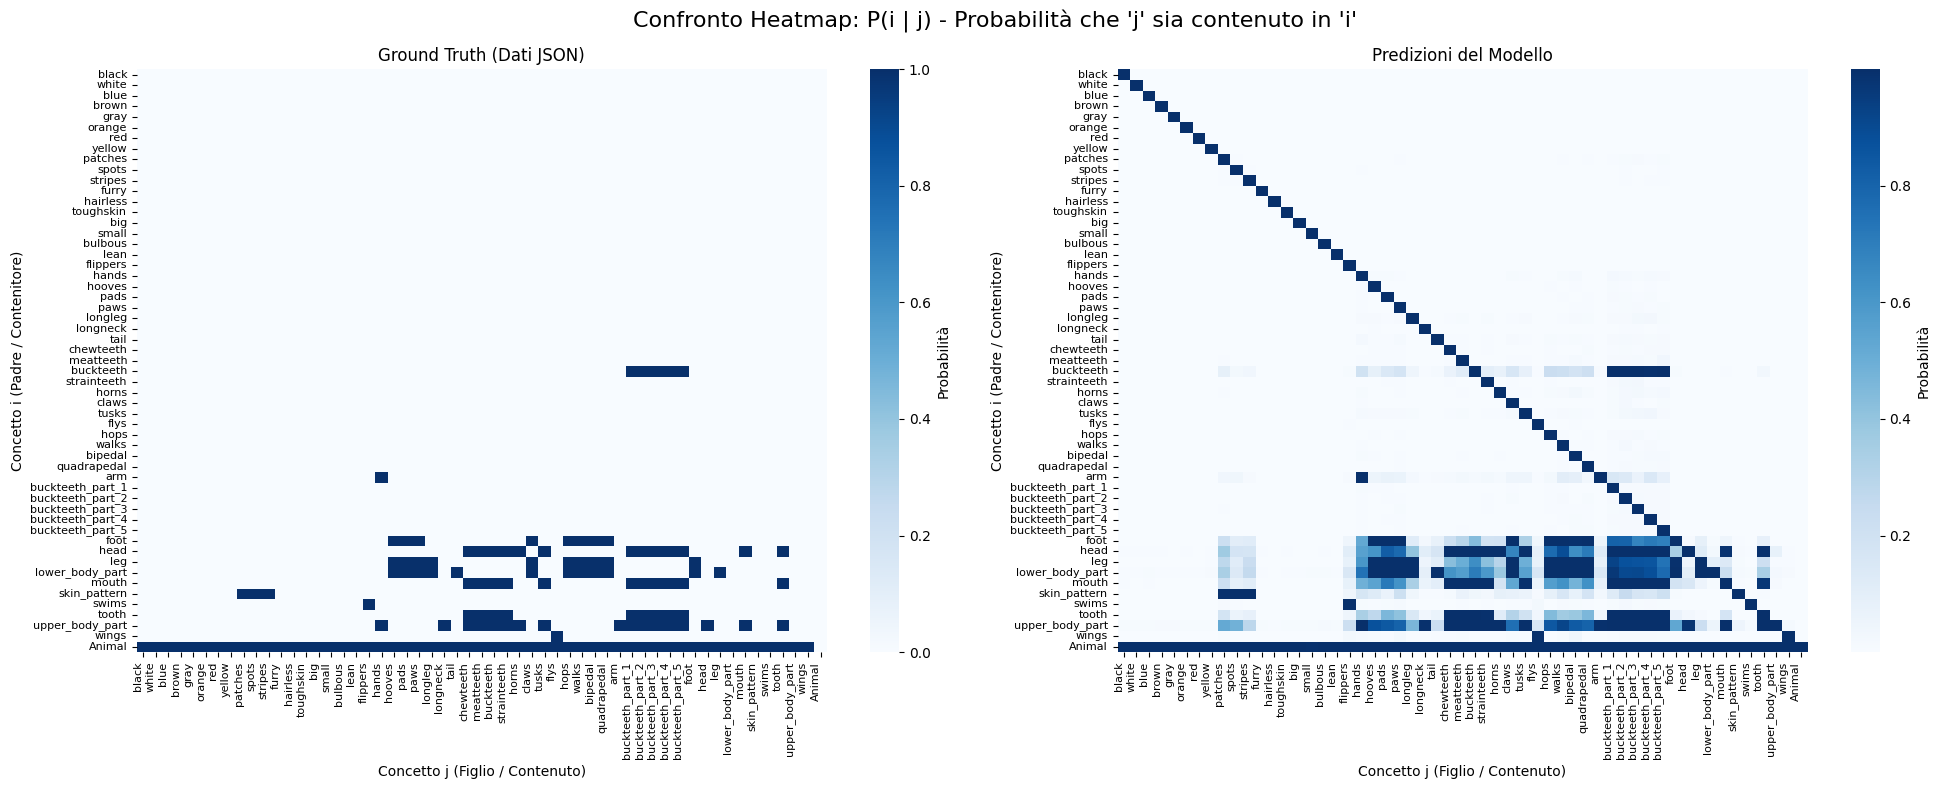

In [10]:
visualize_heatmap_compare(box_model, dataset, concept2id, id2concept)

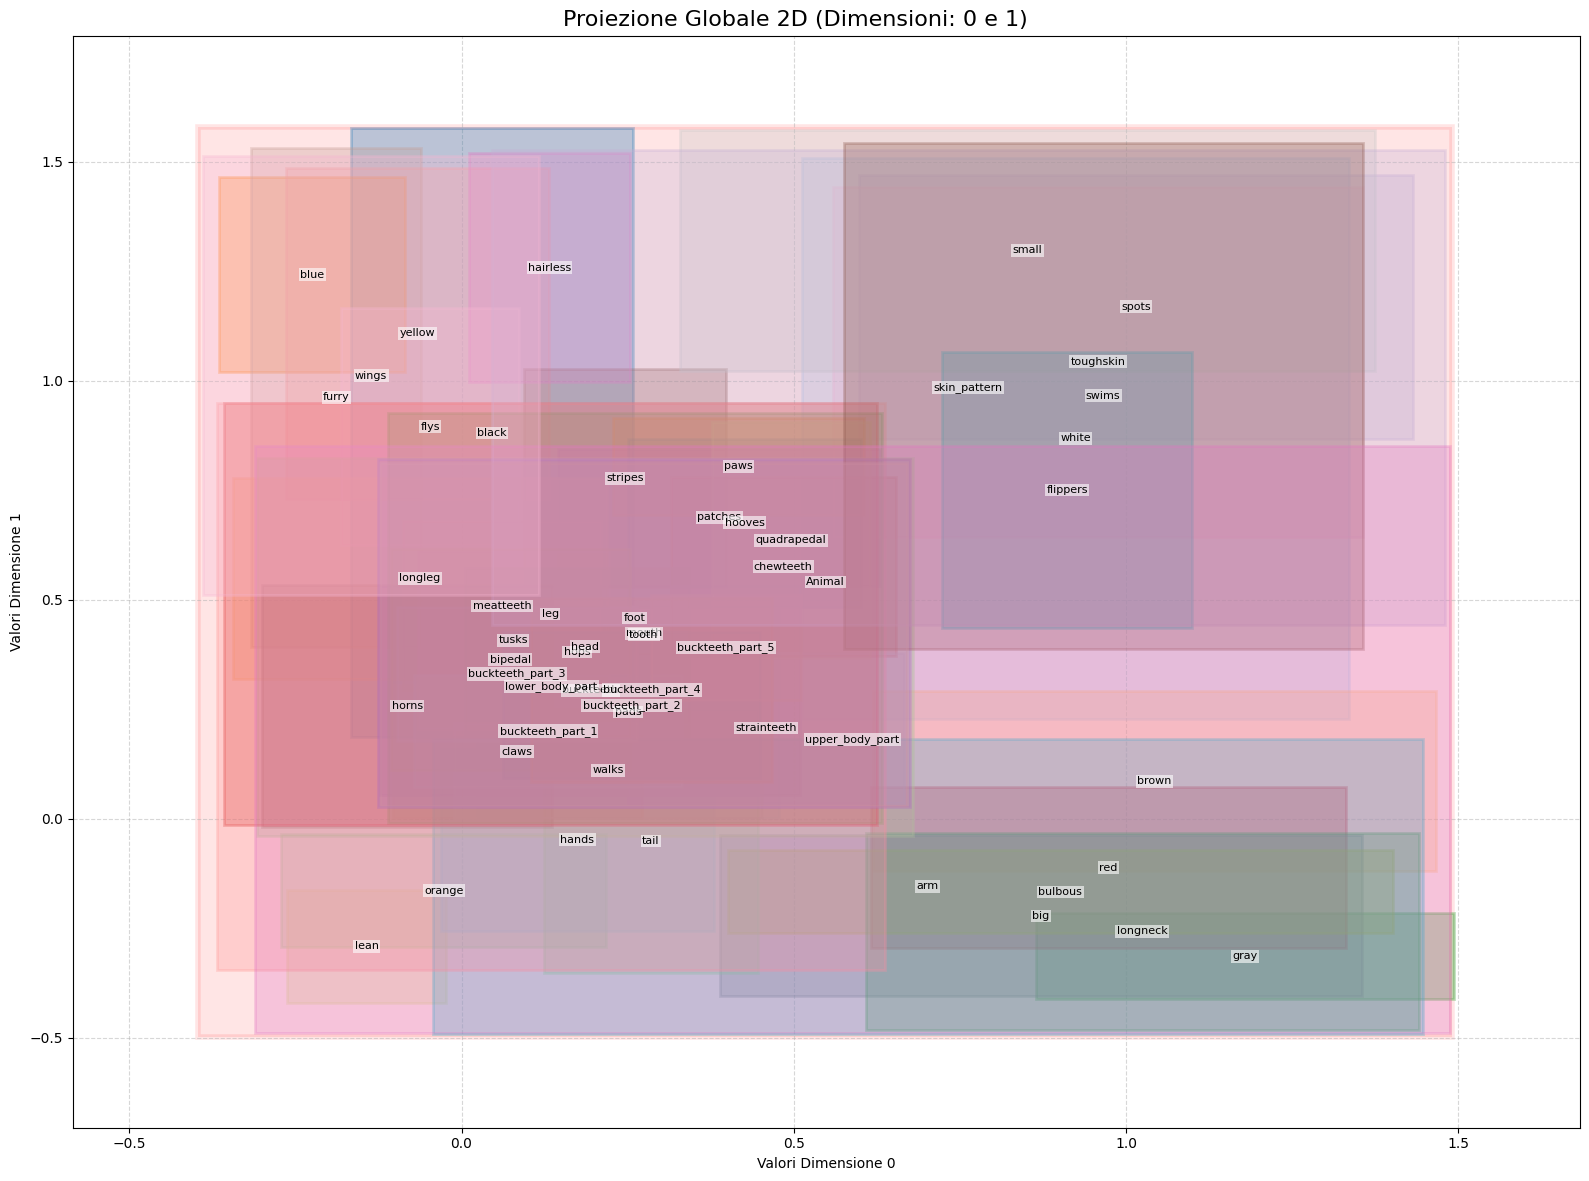

In [11]:
# cambiare dim_x e dim_y (da 0 a 31) per esplorare la "forma" da diverse angolazioni
visualize_all_boxes_2d(box_model, id2concept, dim_x=0, dim_y=1)

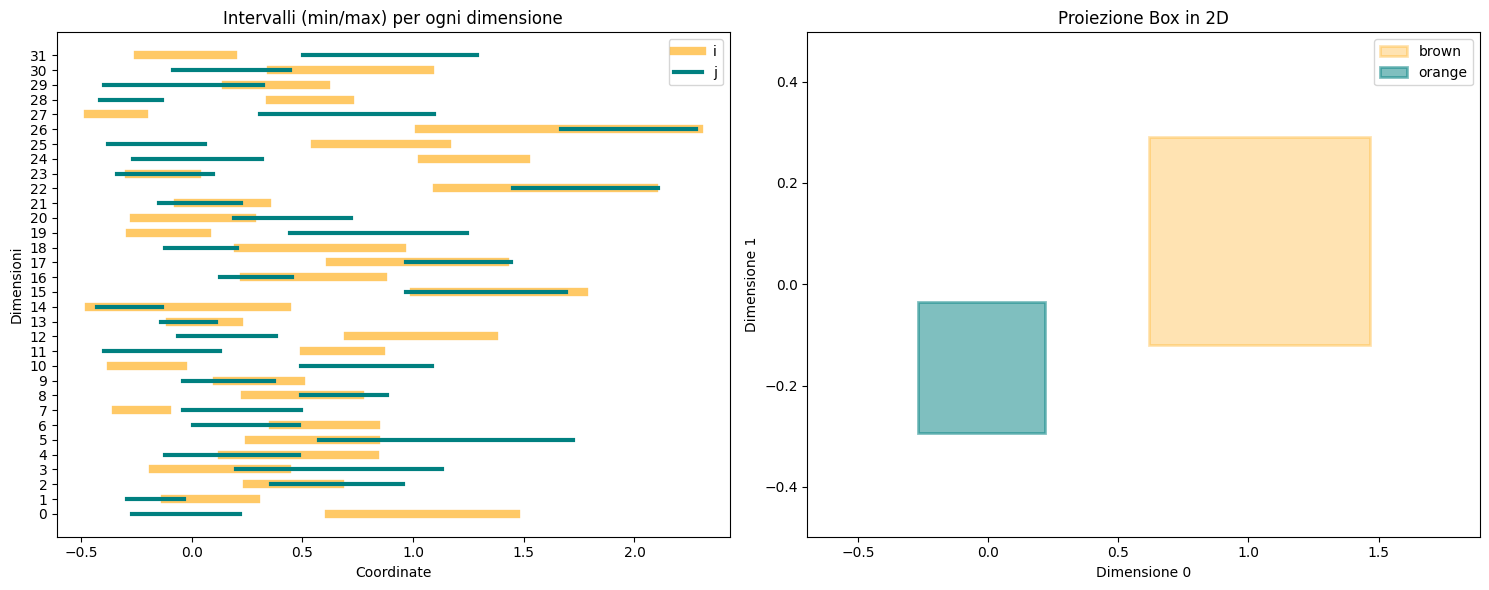

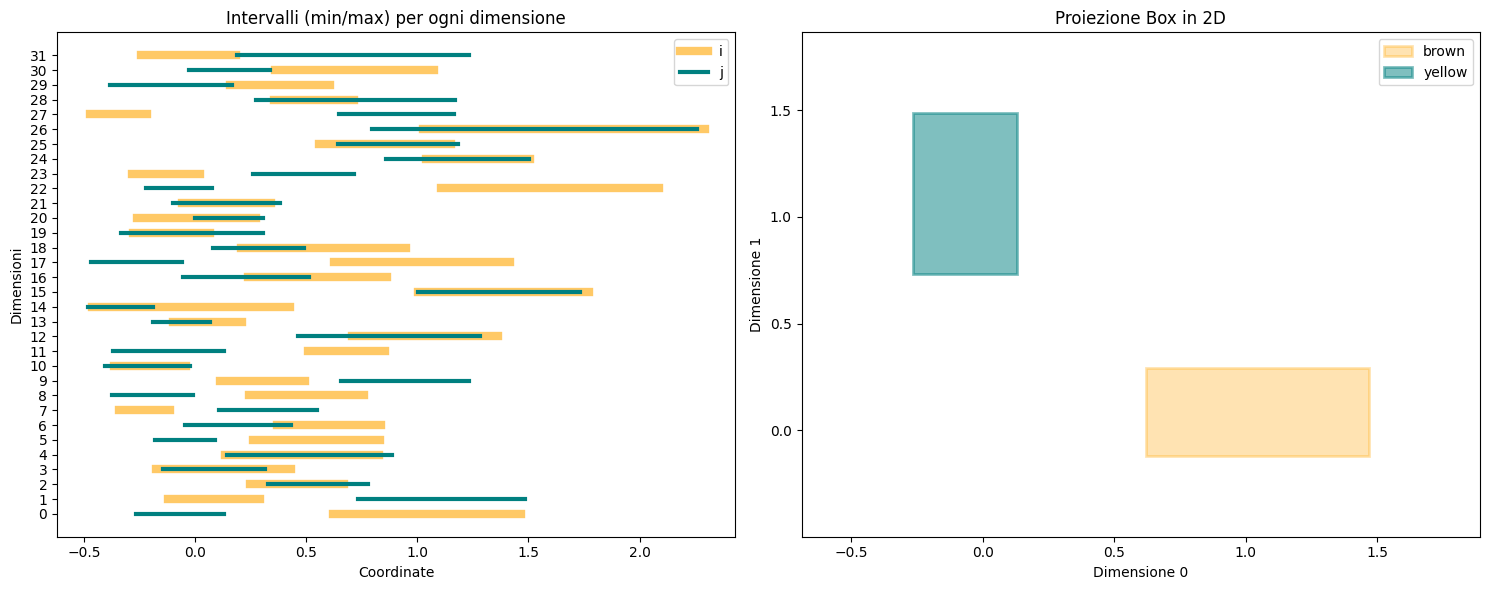

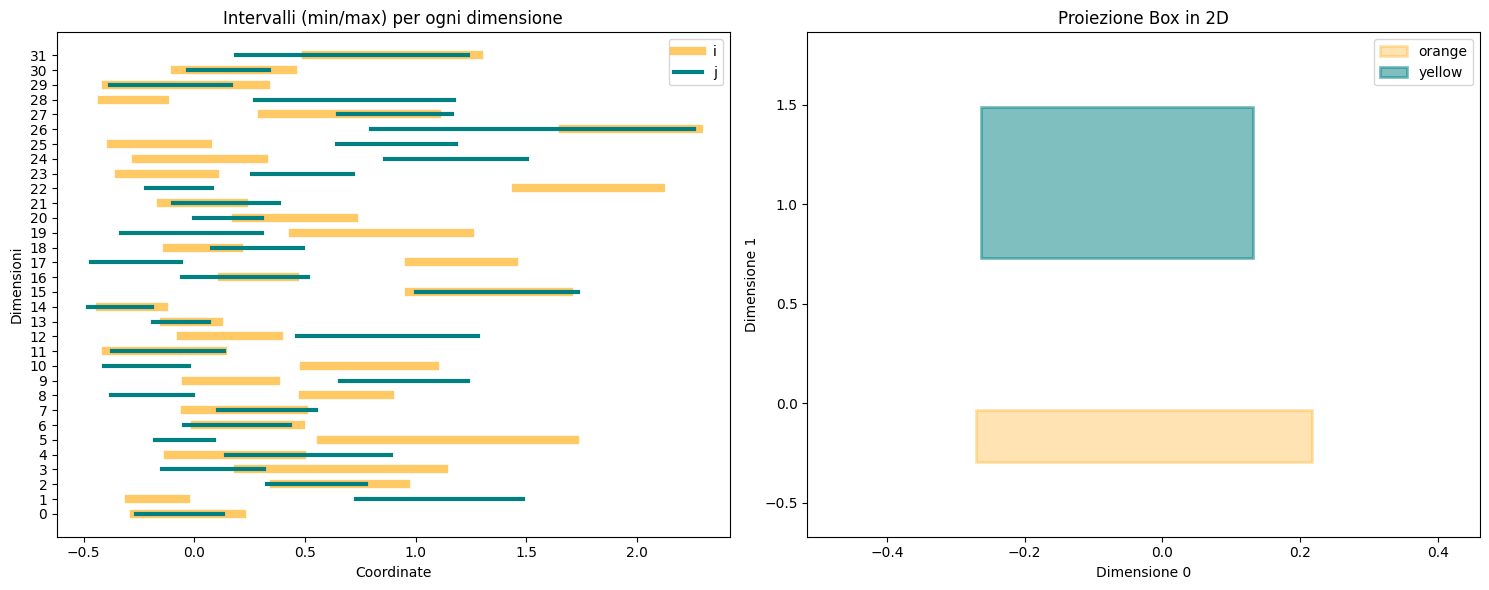

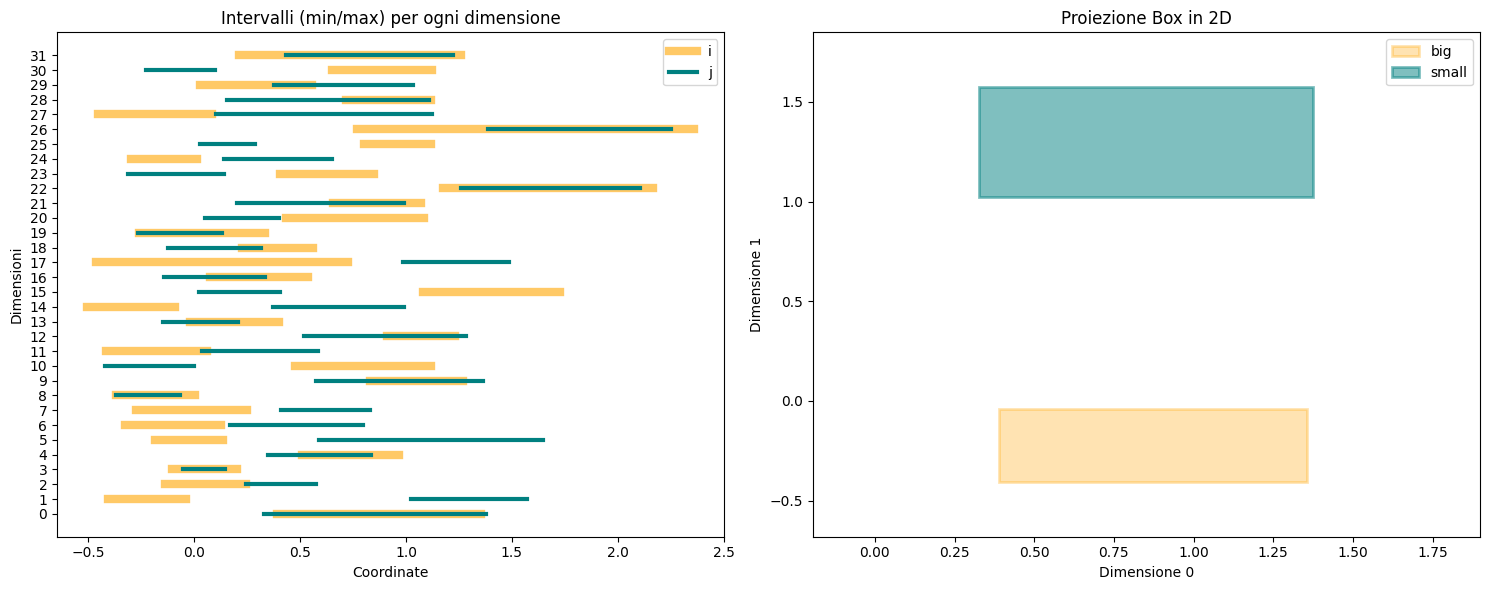

In [12]:
visualize_concept_hierarchy(box_model, id2concept, concept2id, "brown", "orange")
visualize_concept_hierarchy(box_model, id2concept, concept2id, "brown", "yellow")
visualize_concept_hierarchy(box_model, id2concept, concept2id, "orange", "yellow")
visualize_concept_hierarchy(box_model, id2concept, concept2id, "big", "small")

### Save boxes

In [13]:
from src.CHM.model import get_box_dict

box_dict = get_box_dict(box_model, id2concept)

ImportError: cannot import name 'get_box_dict' from 'src.CHM.model' (/Users/stefano_gamba/dev/BoxEmbeddingCBM/src/CHM/model.py)

In [ ]:
box_animale = box_dict["Animal"]
box_ali = box_dict["wings"]

print(f"Coordinate Z (max) per 'Animal': {box_animale.Z}")
print(f"Coordinate z (min) per 'wings': {box_ali.z}")

Coordinate Z (max) per 'Animal': tensor([[1.0045, 1.7231, 1.1192, 1.3872, 1.4232, 0.9403, 0.9683, 0.8890, 1.1328,
         1.2204, 1.1816, 1.0833, 1.5548, 0.9685, 1.6693, 1.1410, 1.8921, 1.8101,
         1.5400, 1.2972, 1.5010, 1.2450, 1.1765, 1.1278, 1.1744, 1.0663, 2.0542,
         2.0776, 1.2245, 1.1324, 1.7535, 1.5863]])
Coordinate z (min) per 'wings': tensor([[-0.1696, -0.3668,  0.1754, -0.2311, -0.0395,  0.1362, -0.2885, -0.1719,
         -0.5532, -0.3358, -0.4071, -0.0431,  0.6643, -0.0316,  0.2674,  0.1523,
          0.0181,  0.0441,  0.5037,  0.3332,  0.1252, -0.2164, -0.3195, -0.4935,
         -0.0202, -0.0716,  0.5814, -0.2487,  0.4289,  0.2898, -0.2042,  0.1971]])


## CBM

### Load dataset

In [17]:
import torch
torch.save(box_model.state_dict(), "modello_gerarchia.pth")

In [18]:
box_model.load_state_dict(torch.load("modello_gerarchia.pth"))

<All keys matched successfully>

In [22]:
from src.utils.box import get_box_dict
box_dict = get_box_dict(box_model, id2concept)

In [23]:
from src.utils.dataset import classical_split_awa2_features
from torch.utils.data import DataLoader, TensorDataset
import numpy as np
from src.utils.box import prepara_tensore_box

features_path = '../AwA2_Dataset_Features/Animals_with_Attributes2/Features/ResNet101/AwA2-features.txt'
labels_path = '../AwA2_Dataset_Features/Animals_with_Attributes2/Features/ResNet101/AwA2-labels.txt'

(X_train, y_train), (X_val, y_val), (X_test, y_test) = classical_split_awa2_features(
    features_path, labels_path, test_size=0.2, val_size=0.1, random_seed=42
)
class_concept_matrix = torch.from_numpy(np.loadtxt('../Awa2_Dataset_Labels/Animals_with_Attributes2/extended_matrix.txt', dtype=int))

box_tensors = prepara_tensore_box(box_dict, concept2id)

BOX_DIM = 32
BATCH_SIZE = 32
EPOCHS = 20
NUM_CLASSES = len(set(y_train))
NUM_CONCEPTS = len(concept2id)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

train_dataset = TensorDataset(torch.tensor(X_train).float(), torch.tensor(y_train).long())
train_dataloader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, pin_memory=True)
val_dataset = TensorDataset(torch.tensor(X_val).float(), torch.tensor(y_val).long())
val_dataloader = DataLoader(val_dataset, batch_size=BATCH_SIZE, pin_memory=True)
test_dataset = TensorDataset(torch.tensor(X_test).float(), torch.tensor(y_test).long())
test_dataloader = DataLoader(test_dataset, batch_size=BATCH_SIZE, pin_memory=True)

Caricamento dei dati in corso... (potrebbe richiedere qualche secondo)
Dataset caricato correttamente: 37322 campioni con 2048 feature ciascuno.

--- Risultati dello Split Stratificato (50 Classi) ---
Training set:   26124 campioni
Validation set: 3733 campioni
Test set:       7465 campioni
Using device: cpu


In [25]:
from src.CHM.model import ConceptBottleneckClassifier
from src.CHM.train import train_cbm_classifier
import matplotlib.pyplot as plt
from src.CHM.test import test_cbm_classifier
from src.utils.plot import plot_test_results, plot_concept_error_heatmap, analyze_misclassifications_concepts

### CBM with boxes

#### Train

In [26]:
b_model = ConceptBottleneckClassifier(box_dim=box_tensors.size(-1), num_classes=NUM_CLASSES, num_concepts=NUM_CONCEPTS)
optimizer = torch.optim.Adam(b_model.parameters(), lr=0.001)
criterion = nn.CrossEntropyLoss()

info = "boxes"

b_history = train_cbm_classifier(
    b_model, 
    train_dataloader, 
    val_dataloader, 
    optimizer, 
    criterion, 
    class_concept_matrix, 
    box_tensors, 
    EPOCHS, 
    device
)

Inizio addestramento del classificatore (c -> y)...
Epoca   2/20 | TRAIN: Loss=0.083, Acc=98.8% | VAL: Loss=0.003, Acc=100.0%
Epoca   3/20 | TRAIN: Loss=0.001, Acc=100.0% | VAL: Loss=0.001, Acc=100.0%
Epoca   4/20 | TRAIN: Loss=0.001, Acc=100.0% | VAL: Loss=0.000, Acc=100.0%
Epoca   5/20 | TRAIN: Loss=0.000, Acc=100.0% | VAL: Loss=0.000, Acc=100.0%
Epoca   6/20 | TRAIN: Loss=0.000, Acc=100.0% | VAL: Loss=0.000, Acc=100.0%
Epoca   7/20 | TRAIN: Loss=0.000, Acc=100.0% | VAL: Loss=0.000, Acc=100.0%
Epoca   8/20 | TRAIN: Loss=0.000, Acc=100.0% | VAL: Loss=0.000, Acc=100.0%
Epoca   9/20 | TRAIN: Loss=0.000, Acc=100.0% | VAL: Loss=0.000, Acc=100.0%
Epoca  10/20 | TRAIN: Loss=0.000, Acc=100.0% | VAL: Loss=0.000, Acc=100.0%
Epoca  11/20 | TRAIN: Loss=0.000, Acc=100.0% | VAL: Loss=0.000, Acc=100.0%
Epoca  12/20 | TRAIN: Loss=0.000, Acc=100.0% | VAL: Loss=0.000, Acc=100.0%
Epoca  13/20 | TRAIN: Loss=0.000, Acc=100.0% | VAL: Loss=0.000, Acc=100.0%
Epoca  14/20 | TRAIN: Loss=0.000, Acc=100.0% | VA

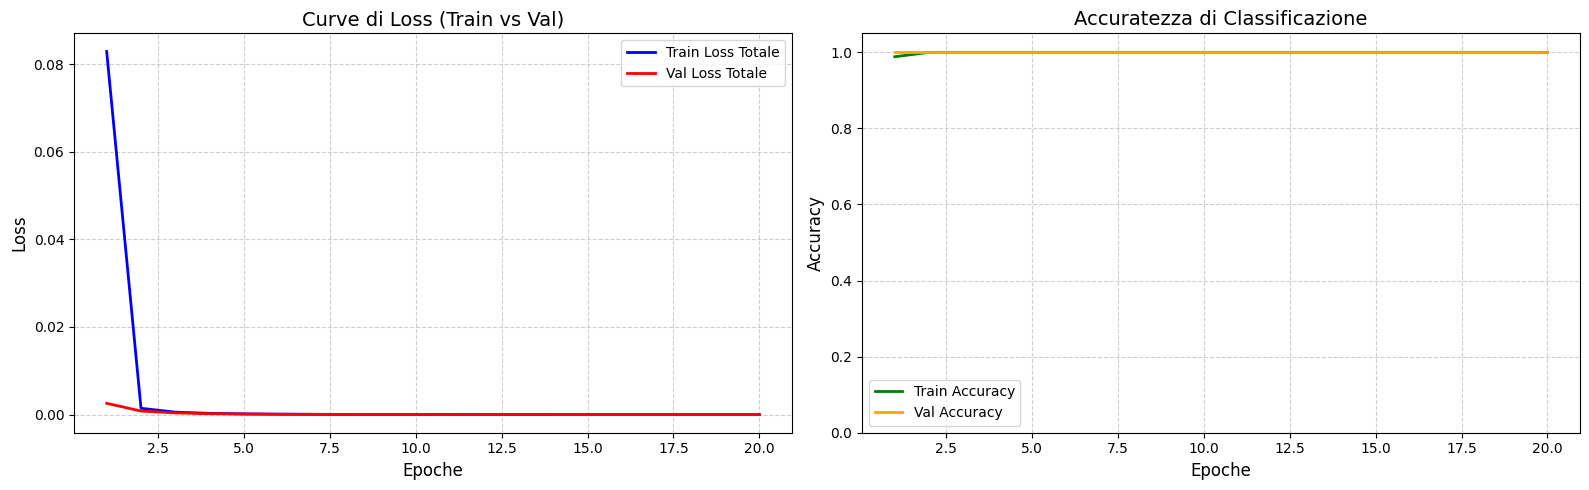

In [27]:
from src.utils.plot import plot_history
plot_history(b_history)

#### Test

In [30]:
accuracy, preds, labels, _, _ = test_cbm_classifier(
     model=b_model,
     test_dataloader=test_dataloader,
     class_concept_matrix=class_concept_matrix,
     boxes_tensor=box_tensors,
     oracle=True,
     device="cuda" if torch.cuda.is_available() else "cpu"
)

Inizio valutazione sul Test Set...

Accuratezza Totale: 100.00%


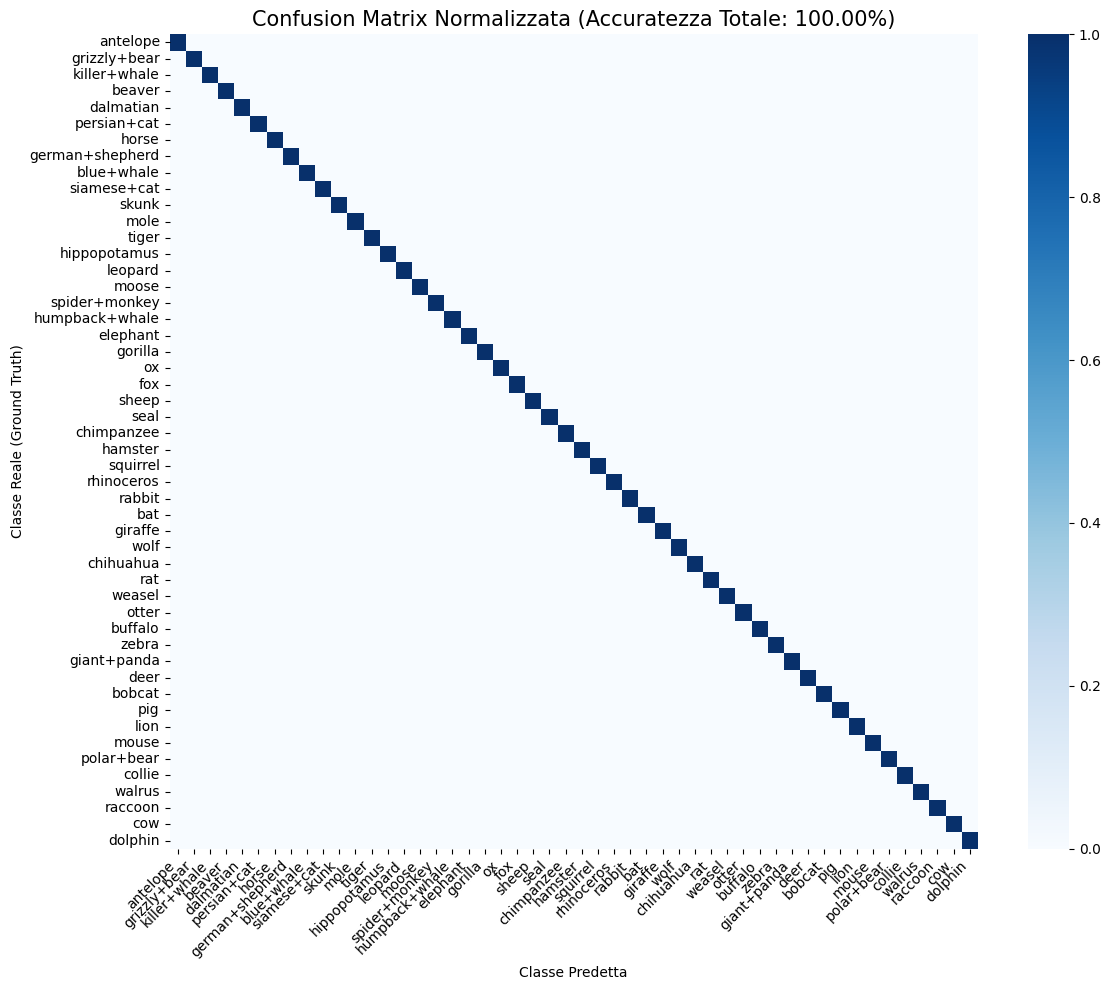


Analisi degli Errori Principali:


In [24]:
plot_test_results(accuracy, preds, labels, class_names=classes)

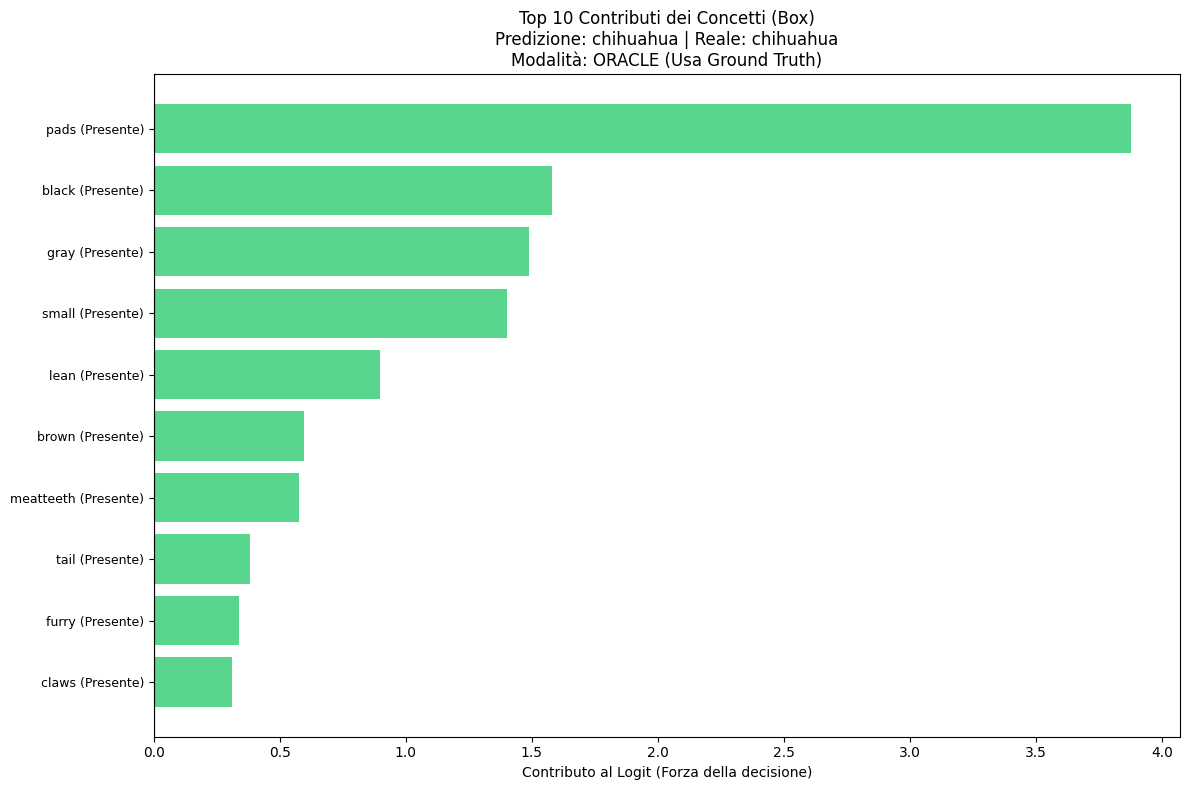

True

In [31]:
from src.CHM.interpretation import explain_prediction

explain_prediction(b_model, test_dataloader, concepts, classes, class_concept_matrix, box_tensors, target_class="chihuahua")

### CBM with cond prob distrib

#### Train

In [32]:
info = "rel_matrix"
bipolar = True
cp_model = ConceptBottleneckClassifier(box_dim=box_tensors.size(-1), num_classes=NUM_CLASSES, num_concepts=NUM_CONCEPTS, info=info)
optimizer = torch.optim.Adam(cp_model.parameters(), lr=0.001)
criterion = nn.CrossEntropyLoss()
cp_history = train_cbm_classifier(
    cp_model, 
    train_dataloader, 
    val_dataloader, 
    optimizer, 
    criterion, 
    class_concept_matrix, 
    box_tensors, 
    EPOCHS, 
    device,
    info=info,
    bipolar=bipolar
)

Inizio addestramento del classificatore (c -> y)...
Epoca   2/20 | TRAIN: Loss=0.397, Acc=95.8% | VAL: Loss=0.046, Acc=100.0%
Epoca   3/20 | TRAIN: Loss=0.026, Acc=100.0% | VAL: Loss=0.014, Acc=100.0%
Epoca   4/20 | TRAIN: Loss=0.010, Acc=100.0% | VAL: Loss=0.007, Acc=100.0%
Epoca   5/20 | TRAIN: Loss=0.005, Acc=100.0% | VAL: Loss=0.004, Acc=100.0%
Epoca   6/20 | TRAIN: Loss=0.003, Acc=100.0% | VAL: Loss=0.002, Acc=100.0%
Epoca   7/20 | TRAIN: Loss=0.002, Acc=100.0% | VAL: Loss=0.001, Acc=100.0%
Epoca   8/20 | TRAIN: Loss=0.001, Acc=100.0% | VAL: Loss=0.001, Acc=100.0%
Epoca   9/20 | TRAIN: Loss=0.001, Acc=100.0% | VAL: Loss=0.001, Acc=100.0%
Epoca  10/20 | TRAIN: Loss=0.000, Acc=100.0% | VAL: Loss=0.000, Acc=100.0%
Epoca  11/20 | TRAIN: Loss=0.000, Acc=100.0% | VAL: Loss=0.000, Acc=100.0%
Epoca  12/20 | TRAIN: Loss=0.000, Acc=100.0% | VAL: Loss=0.000, Acc=100.0%
Epoca  13/20 | TRAIN: Loss=0.000, Acc=100.0% | VAL: Loss=0.000, Acc=100.0%
Epoca  14/20 | TRAIN: Loss=0.000, Acc=100.0% | VA

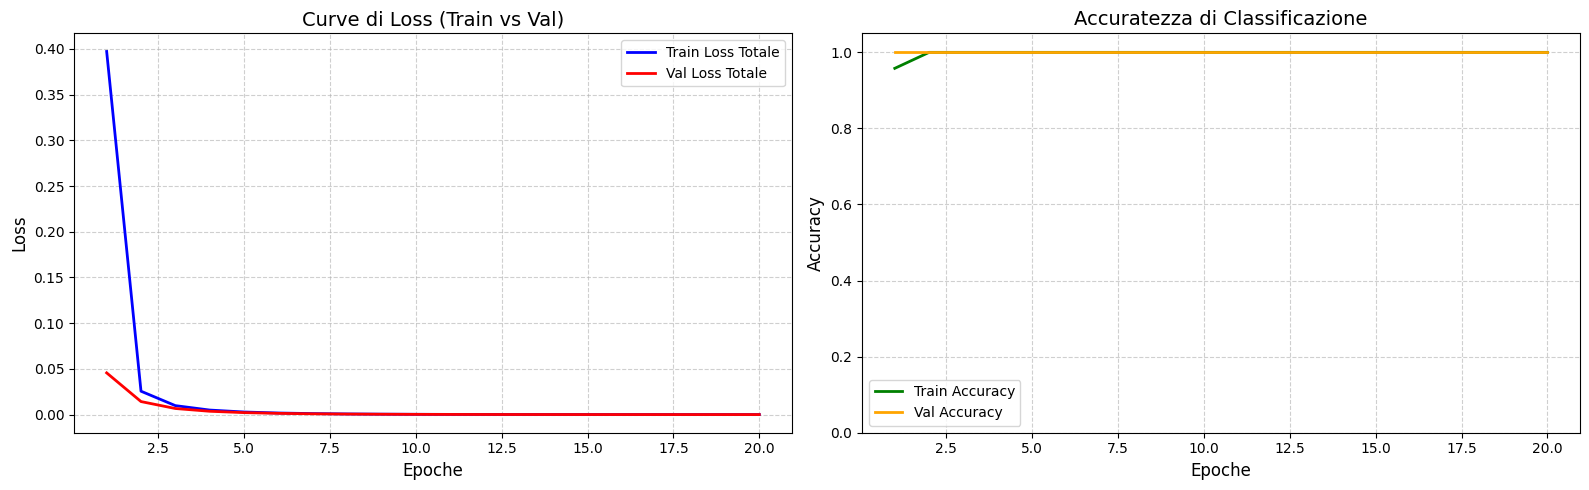

In [34]:
from src.utils.plot import plot_history
plot_history(cp_history)

#### Test

In [35]:
accuracy, preds, labels, _, _ = test_cbm_classifier(
     model=cp_model,
     test_dataloader=test_dataloader,
     class_concept_matrix=class_concept_matrix,
     boxes_tensor=box_tensors,
     device="cuda" if torch.cuda.is_available() else "cpu",
     info=info,
     bipolar=bipolar,
     oracle=True,
)

Inizio valutazione sul Test Set...

Accuratezza Totale: 100.00%


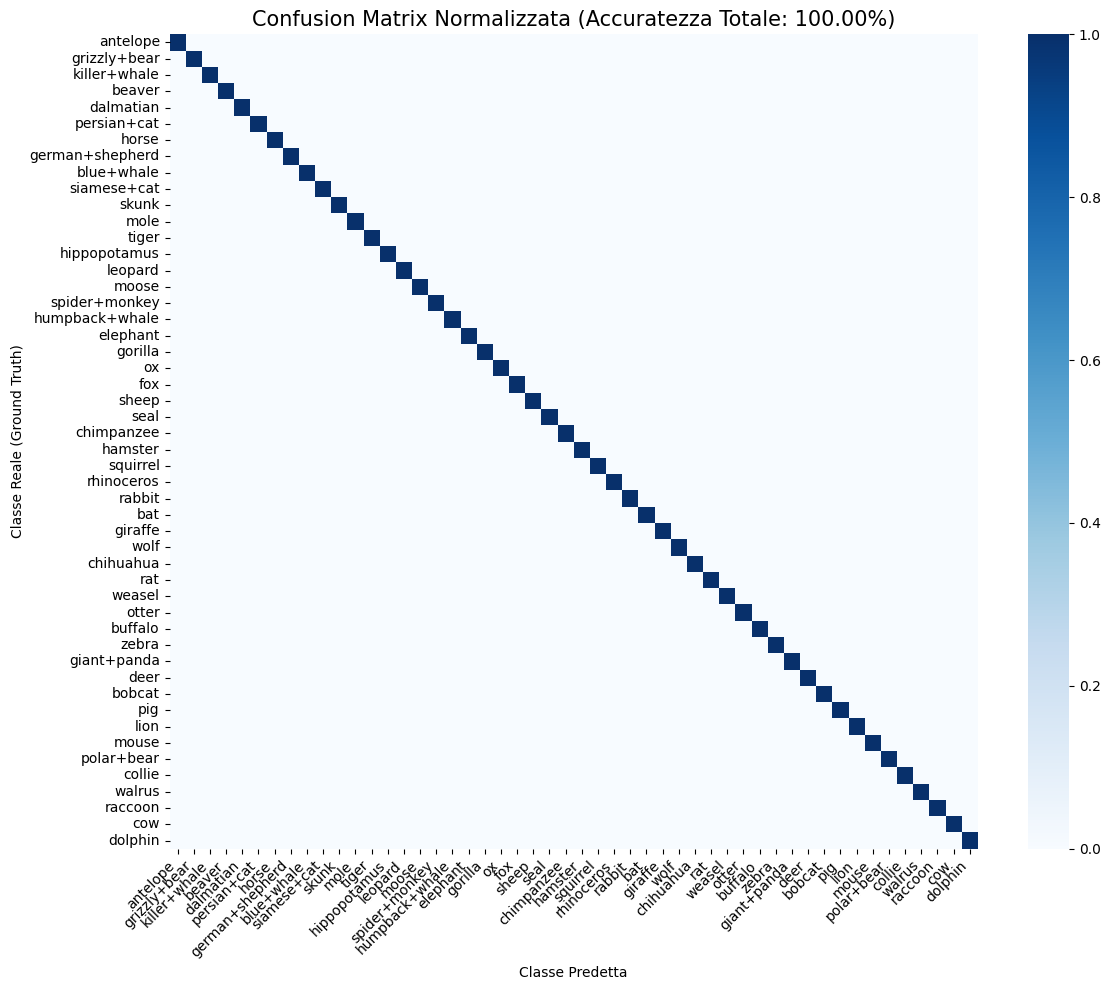


Analisi degli Errori Principali:


In [36]:
plot_test_results(accuracy, preds, labels, class_names=classes)

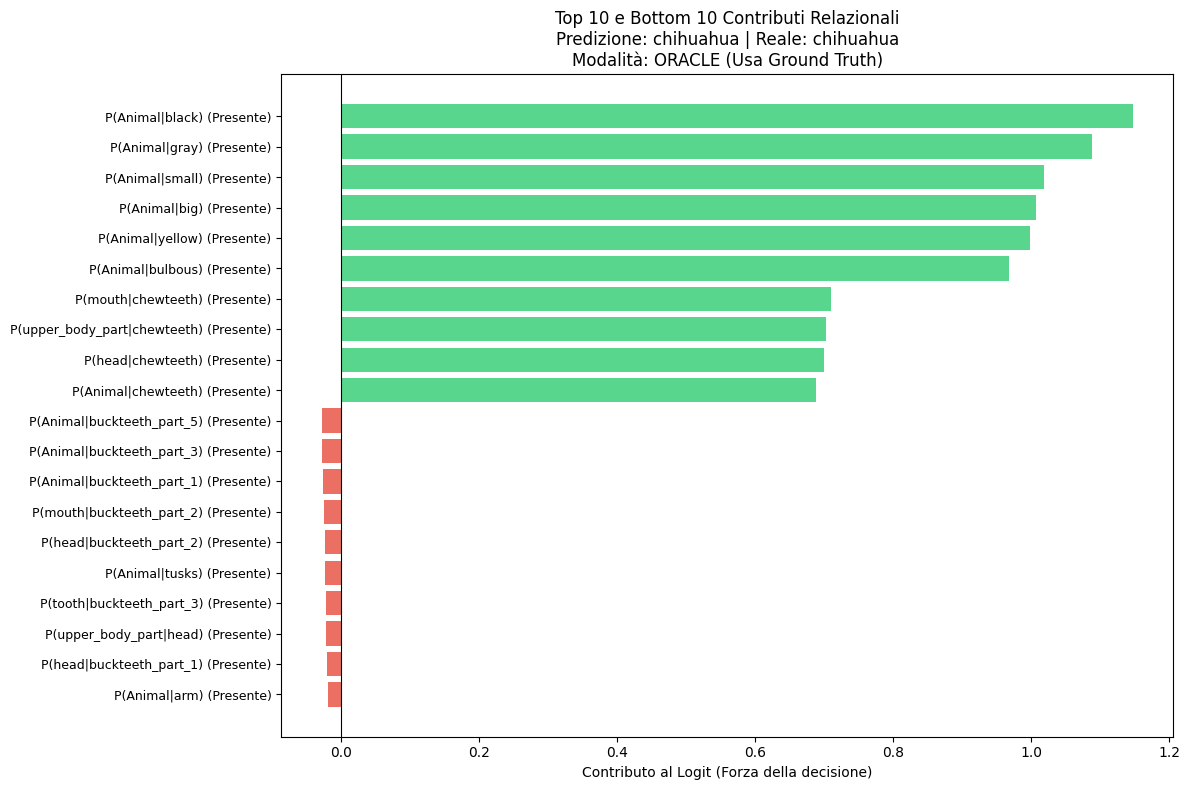

True

In [37]:
from src.CHM.interpretation import explain_prediction

explain_prediction(
    cp_model, 
    test_dataloader, 
    concepts, 
    classes, 
    class_concept_matrix, 
    box_tensors, 
    info_type=info, 
    target_class="chihuahua", 
    bipolar=bipolar
)

### CBM standard

In [38]:
info = "concepts"
c_model = ConceptBottleneckClassifier(box_dim=box_tensors.size(-1), num_classes=NUM_CLASSES, num_concepts=NUM_CONCEPTS, info=info)
optimizer = torch.optim.Adam(c_model.parameters(), lr=0.001)
criterion = nn.CrossEntropyLoss()
c_history = train_cbm_classifier(
    c_model, 
    train_dataloader, 
    val_dataloader, 
    optimizer, 
    criterion, 
    class_concept_matrix, 
    box_tensors, 
    EPOCHS, 
    device,
    info=info
)

Inizio addestramento del classificatore (c -> y)...
Epoca   2/20 | TRAIN: Loss=1.558, Acc=82.7% | VAL: Loss=0.495, Acc=99.2%
Epoca   3/20 | TRAIN: Loss=0.280, Acc=99.8% | VAL: Loss=0.155, Acc=100.0%
Epoca   4/20 | TRAIN: Loss=0.107, Acc=100.0% | VAL: Loss=0.073, Acc=100.0%
Epoca   5/20 | TRAIN: Loss=0.054, Acc=100.0% | VAL: Loss=0.040, Acc=100.0%
Epoca   6/20 | TRAIN: Loss=0.031, Acc=100.0% | VAL: Loss=0.024, Acc=100.0%
Epoca   7/20 | TRAIN: Loss=0.019, Acc=100.0% | VAL: Loss=0.015, Acc=100.0%
Epoca   8/20 | TRAIN: Loss=0.012, Acc=100.0% | VAL: Loss=0.010, Acc=100.0%
Epoca   9/20 | TRAIN: Loss=0.008, Acc=100.0% | VAL: Loss=0.007, Acc=100.0%
Epoca  10/20 | TRAIN: Loss=0.005, Acc=100.0% | VAL: Loss=0.004, Acc=100.0%
Epoca  11/20 | TRAIN: Loss=0.004, Acc=100.0% | VAL: Loss=0.003, Acc=100.0%
Epoca  12/20 | TRAIN: Loss=0.002, Acc=100.0% | VAL: Loss=0.002, Acc=100.0%
Epoca  13/20 | TRAIN: Loss=0.002, Acc=100.0% | VAL: Loss=0.001, Acc=100.0%
Epoca  14/20 | TRAIN: Loss=0.001, Acc=100.0% | VAL:

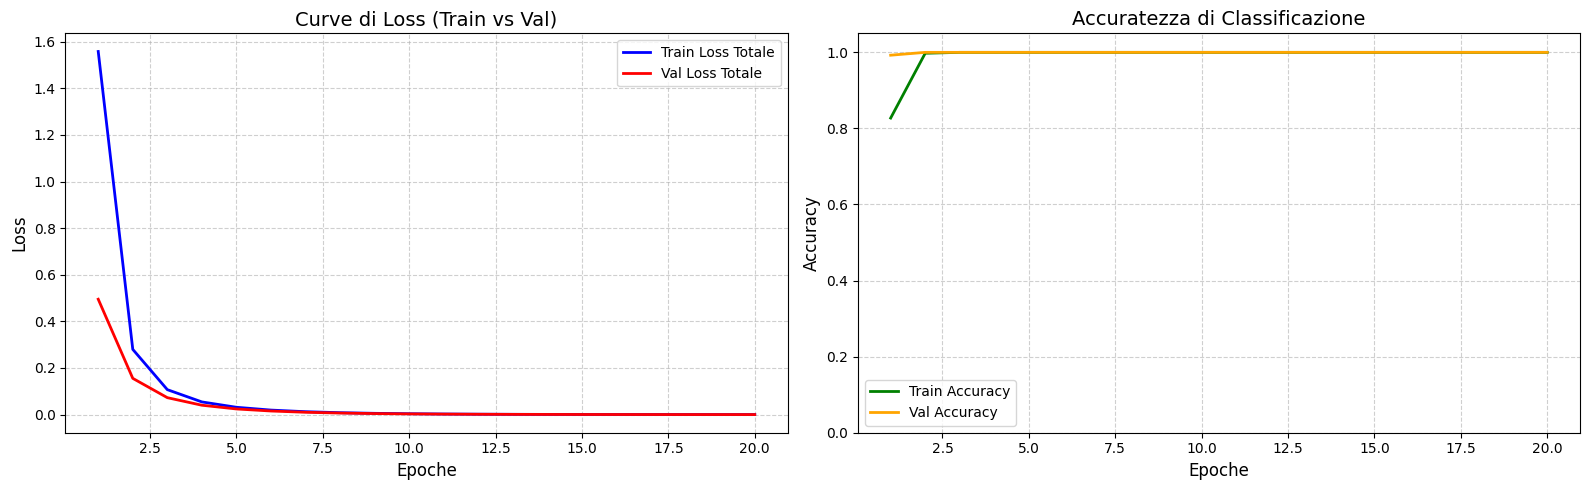

In [39]:
from src.utils.plot import plot_history
plot_history(c_history)

In [40]:
accuracy, preds, labels, _, _ = test_cbm_classifier(
     model=c_model,
     test_dataloader=test_dataloader,
     class_concept_matrix=class_concept_matrix,
     boxes_tensor=box_tensors,
     device="cuda" if torch.cuda.is_available() else "cpu",
     info=info,
     oracle=True,
)

Inizio valutazione sul Test Set...

Accuratezza Totale: 100.00%


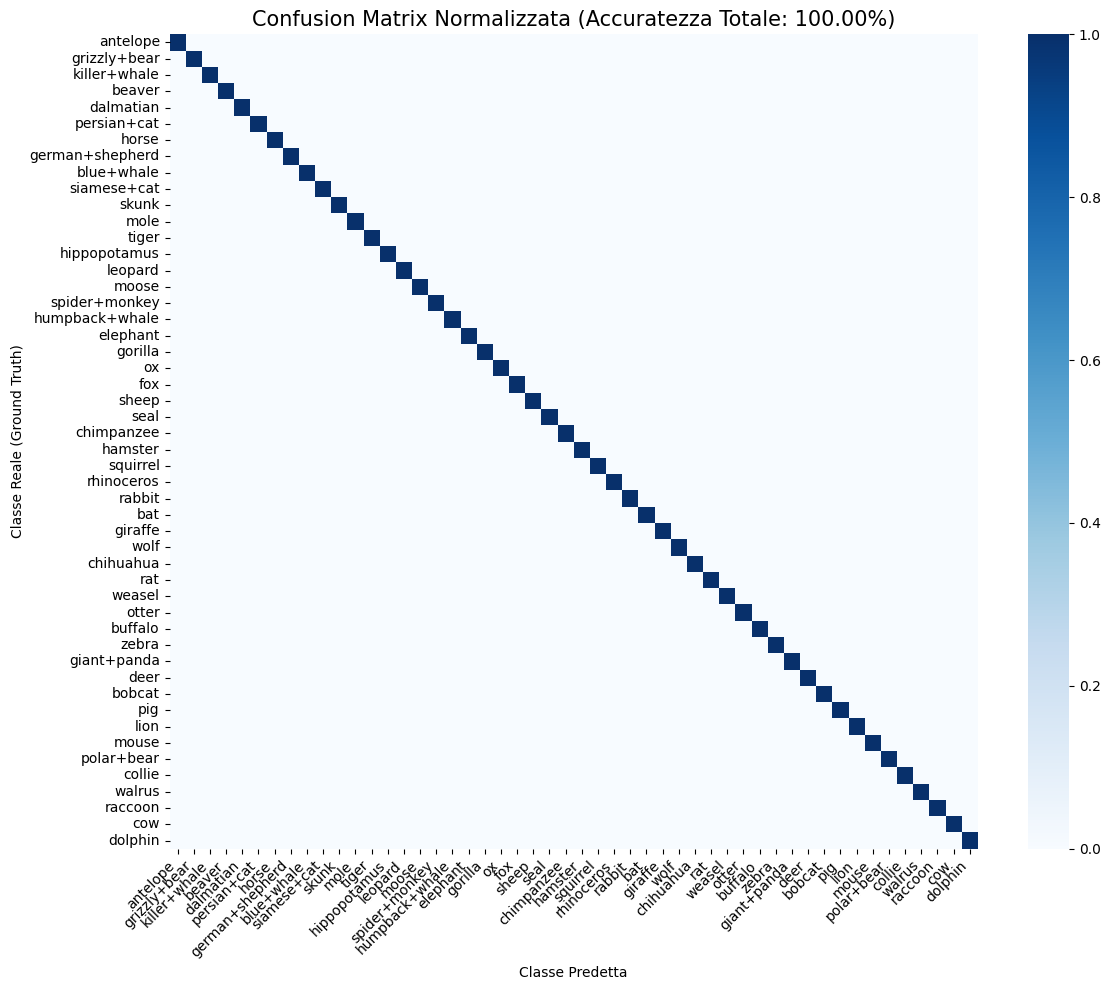


Analisi degli Errori Principali:


In [41]:
plot_test_results(accuracy, preds, labels, class_names=classes)

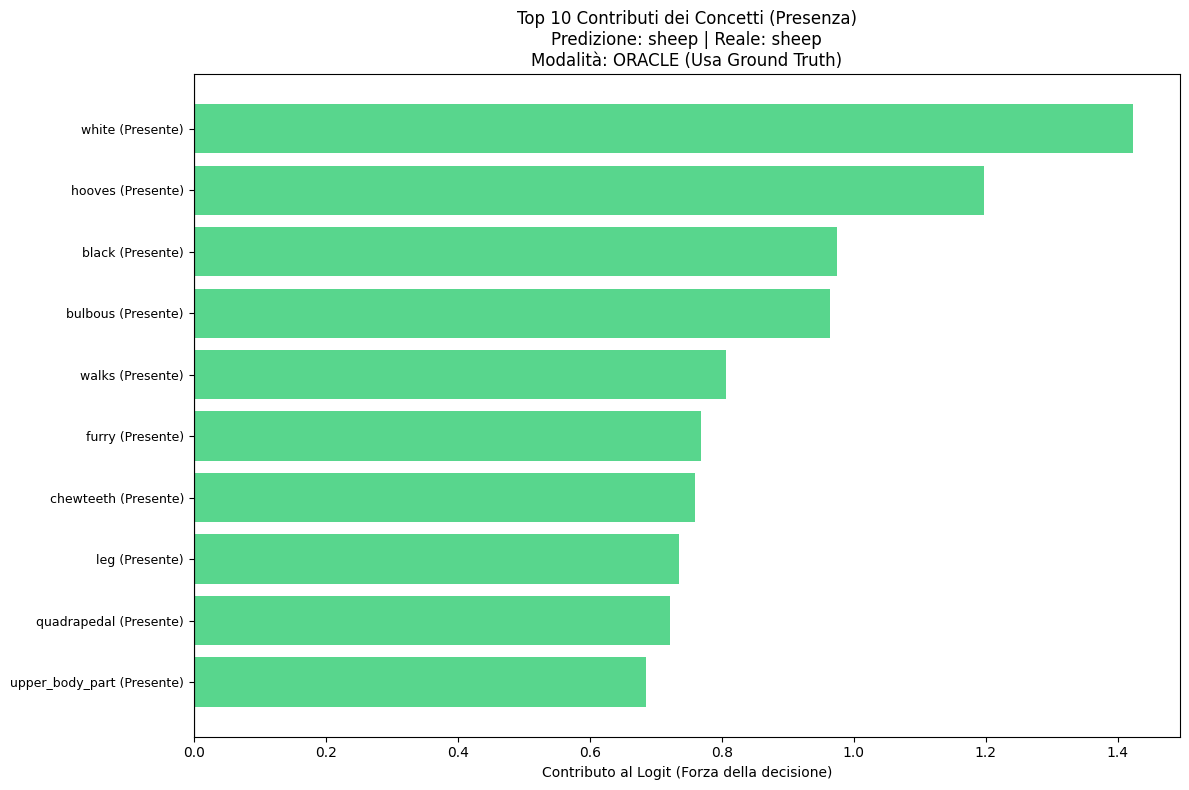

True

In [42]:
from src.CHM.interpretation import explain_prediction

explain_prediction(c_model, test_dataloader, concepts, classes, class_concept_matrix, box_tensors, info_type=info)

## Concept Predictor

In [43]:
from src.CHM.model import ConceptPredictor

concept_predictor = ConceptPredictor(X_train.shape[1], num_concepts=NUM_CONCEPTS)
optimizer = torch.optim.Adam(concept_predictor.parameters(), lr=0.001)
criterion = nn.BCEWithLogitsLoss()

In [44]:
from src.CHM.train import train_concept_predictor

history = train_concept_predictor(
    concept_predictor, 
    train_dataloader, 
    val_dataloader, 
    class_concept_matrix, 
    optimizer, 
    criterion, 
    EPOCHS, 
    device
)

Loss: 3.3583 | Acc: 96.2076 || Val Loss: 2.3998 | Val Acc: 97.2301
Loss: 2.0934 | Acc: 97.6108 || Val Loss: 2.1485 | Val Acc: 97.4956
Loss: 1.8163 | Acc: 97.9212 || Val Loss: 2.0348 | Val Acc: 97.6222
Loss: 1.6523 | Acc: 98.0965 || Val Loss: 2.0341 | Val Acc: 97.6154
Loss: 1.5352 | Acc: 98.2218 || Val Loss: 1.9933 | Val Acc: 97.6714
Loss: 1.4491 | Acc: 98.3300 || Val Loss: 1.9741 | Val Acc: 97.7147
Loss: 1.3773 | Acc: 98.4118 || Val Loss: 2.0330 | Val Acc: 97.6246
Loss: 1.3161 | Acc: 98.4897 || Val Loss: 2.0052 | Val Acc: 97.7152
Loss: 1.2639 | Acc: 98.5384 || Val Loss: 2.0539 | Val Acc: 97.6480
Loss: 1.2316 | Acc: 98.5883 || Val Loss: 2.0699 | Val Acc: 97.6407
Loss: 1.1943 | Acc: 98.6168 || Val Loss: 2.0448 | Val Acc: 97.7055
Loss: 1.1571 | Acc: 98.6654 || Val Loss: 2.0625 | Val Acc: 97.7035
Loss: 1.1300 | Acc: 98.6933 || Val Loss: 2.0746 | Val Acc: 97.6763
Loss: 1.1068 | Acc: 98.7262 || Val Loss: 2.1020 | Val Acc: 97.7035
Loss: 1.0845 | Acc: 98.7525 || Val Loss: 2.1274 | Val Acc: 97.

In [45]:
info = "boxes"
b_accuracy, b_preds, b_labels, b_concepts_preds, b_concepts_truth = test_cbm_classifier(
     model=b_model,
     test_dataloader=test_dataloader,
     class_concept_matrix=class_concept_matrix,
     boxes_tensor=box_tensors,
     device="cuda" if torch.cuda.is_available() else "cpu",
     info=info,
     bipolar=False,
     oracle=False,
     concept_predictor=concept_predictor
)

Inizio valutazione sul Test Set...

Accuratezza Totale: 90.26%


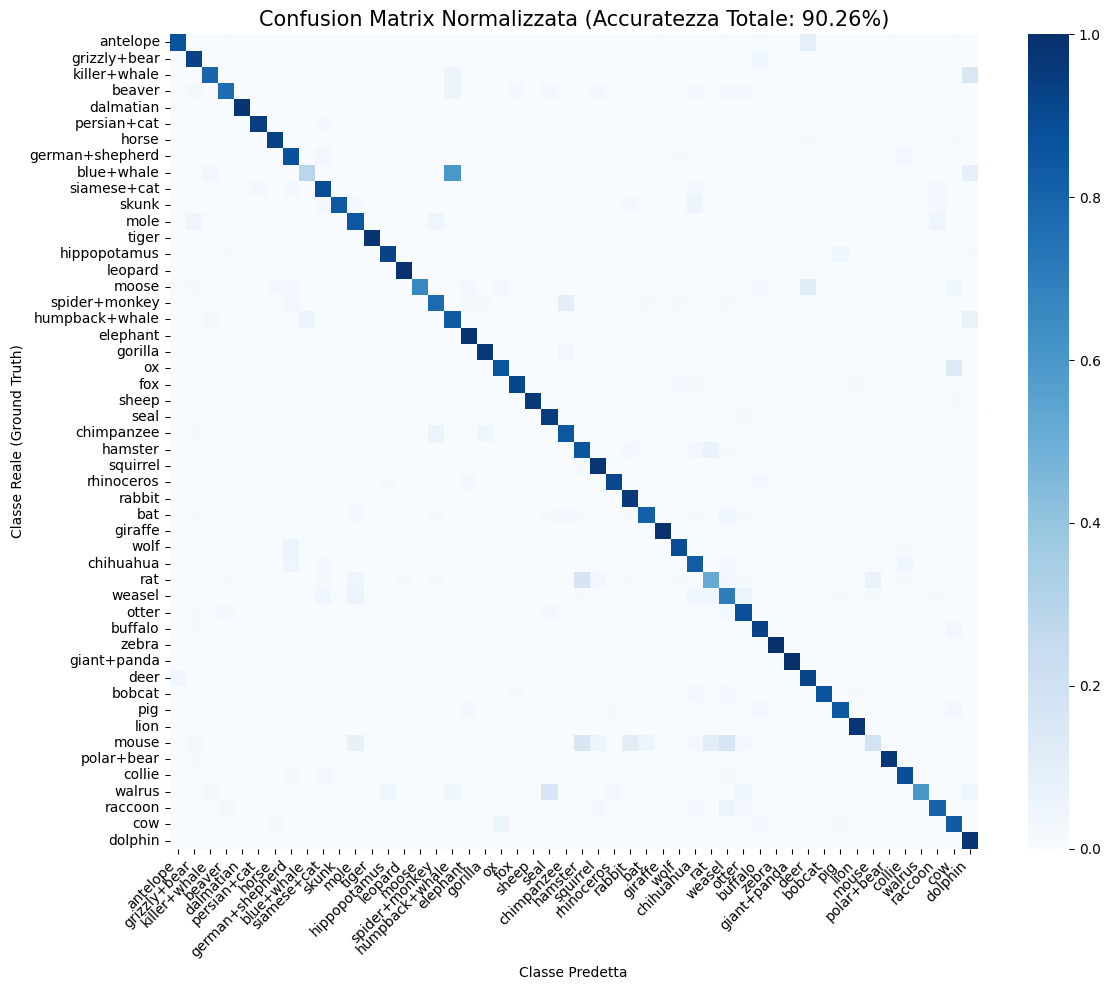


Analisi degli Errori Principali:
 - 21 volte: 'blue+whale' è stato scambiato per 'humpback+whale'
 - 19 volte: 'ox' è stato scambiato per 'cow'
 - 19 volte: 'antelope' è stato scambiato per 'deer'
 - 16 volte: 'moose' è stato scambiato per 'deer'
 - 15 volte: 'cow' è stato scambiato per 'ox'


In [46]:
plot_test_results(b_accuracy, b_preds, b_labels, class_names=classes)

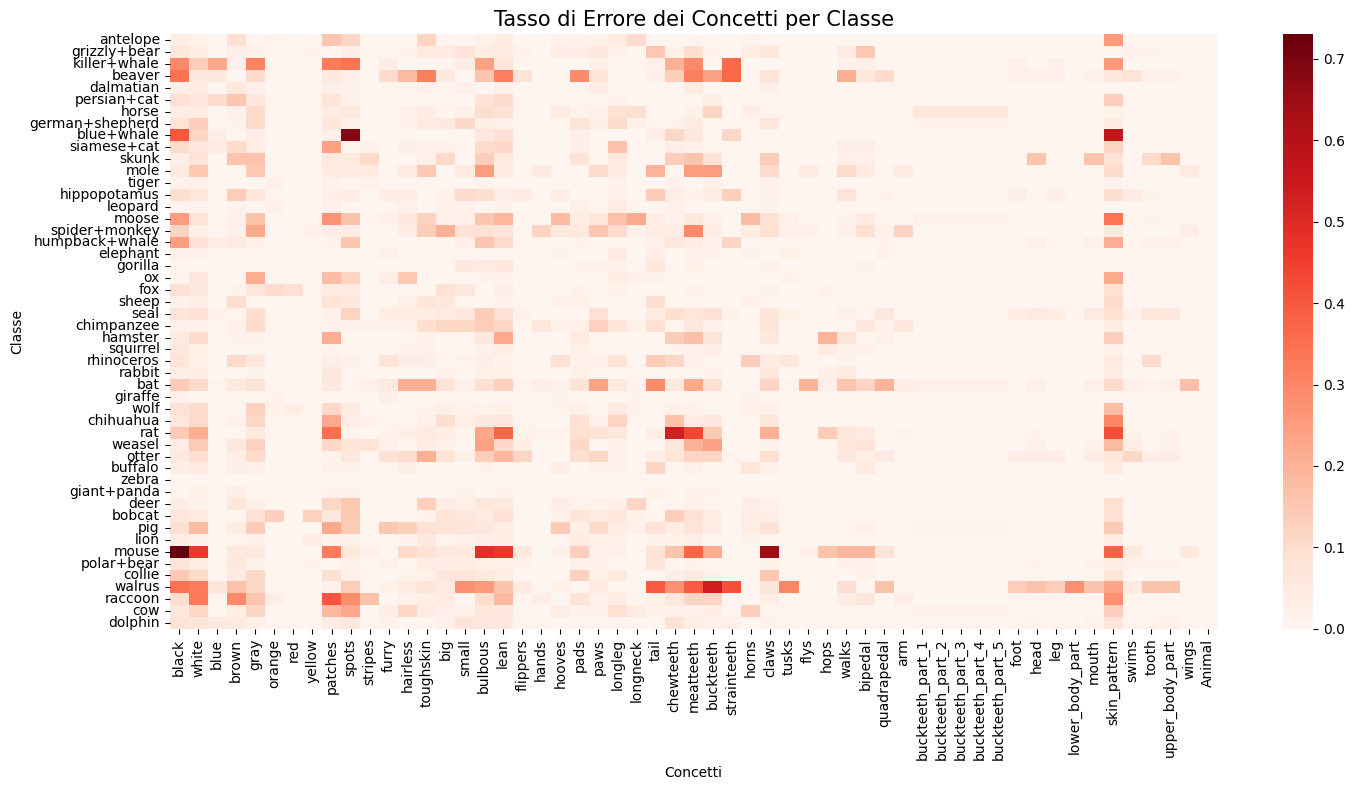

In [47]:
plot_concept_error_heatmap(labels,b_concepts_preds, b_concepts_truth, classes, concepts)

In [49]:
analyze_misclassifications_concepts(b_preds, b_labels, b_concepts_preds, b_concepts_truth, classes, concepts, num_examples=10)


--- ANALISI DEI CONCETTI SUGLI ERRORI (Mostrando 10 esempi) ---

[Esempio Errato #1 - Indice Batch: 3]
Classe Reale: 'collie' ---> Classe Predetta: 'polar+bear'
Concetti Sbagliati (Falsi Positivi / Falsi Negativi):
  - [white] Falso Negativo: Doveva essere VERO, il modello ha detto FALSO.
  - [brown] Falso Negativo: Doveva essere VERO, il modello ha detto FALSO.
  - [patches] Falso Negativo: Doveva essere VERO, il modello ha detto FALSO.
  - [small] Falso Negativo: Doveva essere VERO, il modello ha detto FALSO.
  - [bulbous] Falso Positivo: Doveva essere FALSO, il modello ha detto VERO.
  - [lean] Falso Negativo: Doveva essere VERO, il modello ha detto FALSO.
  - [pads] Falso Positivo: Doveva essere FALSO, il modello ha detto VERO.
  - [claws] Falso Positivo: Doveva essere FALSO, il modello ha detto VERO.
  - [skin_pattern] Falso Negativo: Doveva essere VERO, il modello ha detto FALSO.

[Esempio Errato #2 - Indice Batch: 7]
Classe Reale: 'walrus' ---> Classe Predetta: 'otter'
Concetti

In [51]:
info = "rel_matrix"
cp_accuracy, cp_preds, cp_labels, cp_concepts_preds, cp_concepts_truth = test_cbm_classifier(
     model=cp_model,
     test_dataloader=test_dataloader,
     class_concept_matrix=class_concept_matrix,
     boxes_tensor=box_tensors,
     device="cuda" if torch.cuda.is_available() else "cpu",
     info=info,
     bipolar=False,
     oracle=False,
     concept_predictor=concept_predictor
)

Inizio valutazione sul Test Set...

Accuratezza Totale: 69.65%


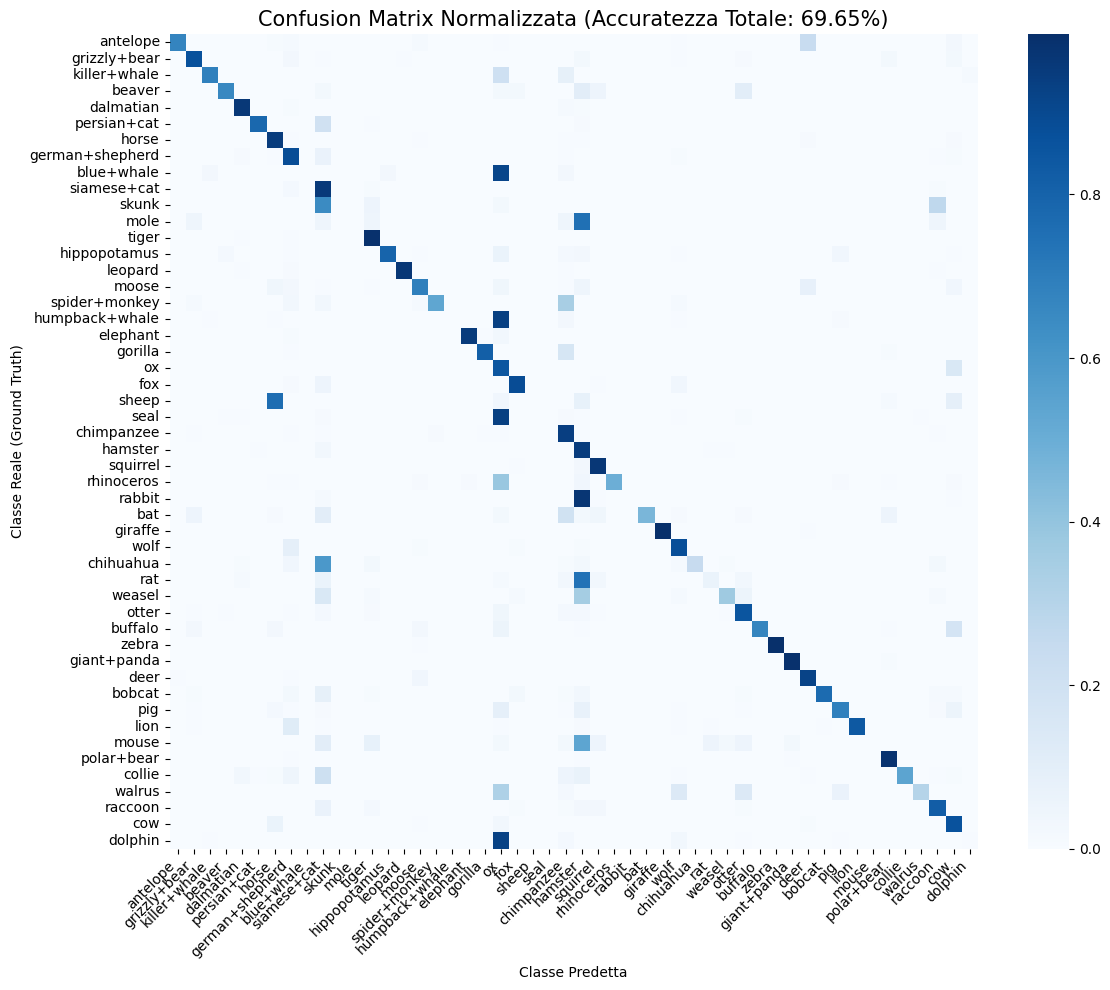


Analisi degli Errori Principali:
 - 216 volte: 'sheep' è stato scambiato per 'horse'
 - 212 volte: 'rabbit' è stato scambiato per 'hamster'
 - 185 volte: 'seal' è stato scambiato per 'ox'
 - 175 volte: 'dolphin' è stato scambiato per 'ox'
 - 133 volte: 'humpback+whale' è stato scambiato per 'ox'


In [52]:
plot_test_results(cp_accuracy, cp_preds, cp_labels, class_names=classes)

In [44]:
info = "concepts"
c_accuracy, c_preds, c_labels = test_cbm_classifier(
     model=c_model,
     test_dataloader=test_dataloader,
     class_concept_matrix=class_concept_matrix,
     boxes_tensor=box_tensors,
     device="cuda" if torch.cuda.is_available() else "cpu",
     info=info,
     bipolar=False,
     oracle=False,
     concept_predictor=concept_predictor
)

Inizio valutazione sul Test Set...

Risultati Test Set:
Accuratezza Totale: 90.05% (6722/7465)

Classification Report (prime 10 classi):
              precision    recall  f1-score   support

           0       0.83      0.92      0.87       209
           1       0.91      0.90      0.90       170
           2       0.85      0.78      0.81        58
           3       0.76      0.82      0.78        38
           4       0.96      0.98      0.97       110
           5       0.90      0.97      0.93       149
           6       0.97      0.92      0.95       329
           7       0.91      0.84      0.87       207
           8       0.57      0.23      0.33        35
           9       0.84      0.79      0.81       100

   micro avg       0.90      0.88      0.89      1405
   macro avg       0.85      0.81      0.82      1405
weighted avg       0.89      0.88      0.89      1405



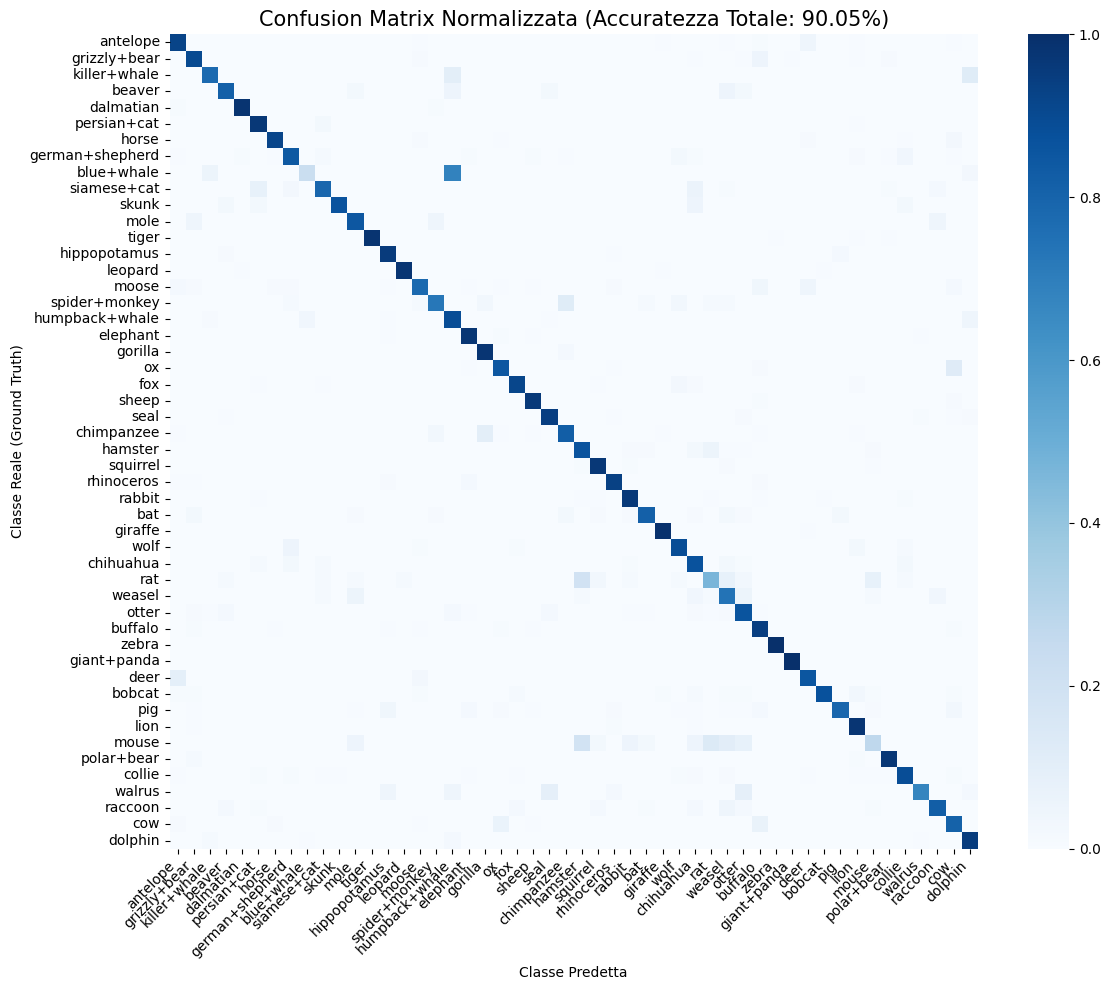


Analisi degli Errori Principali:
 - 26 volte: 'deer' è stato scambiato per 'antelope'
 - 24 volte: 'blue+whale' è stato scambiato per 'humpback+whale'
 - 19 volte: 'cow' è stato scambiato per 'buffalo'
 - 18 volte: 'ox' è stato scambiato per 'cow'
 - 17 volte: 'cow' è stato scambiato per 'ox'


In [45]:
plot_test_results(c_accuracy, c_preds, c_labels, class_names=classes)